In [4]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn ipywidgets

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from ipywidgets import interact, widgets

# Show matplotlib plots inside the notebook
%matplotlib inline

In [9]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")


In [10]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [11]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
# ---------------------------------------------
# 3️⃣ DATA CLEANING
# ---------------------------------------------
# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Fill missing values safely
df['director'] = df['director'].fillna("Unknown Director")
df['cast'] = df['cast'].fillna("Unknown Cast")
df['country'] = df['country'].fillna("Unknown Country")

# Combine text features for recommendation system
df['text_features'] = df['title'].fillna('') + " " + df['listed_in'].fillna('') + " " + df['description'].fillna('')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,text_features
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Cast,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Dick Johnson Is Dead Documentaries As her fath...
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...","Blood & Water International TV Shows, TV Drama..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown Country,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,"Ganglands Crime TV Shows, International TV Sho..."
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Unknown Cast,Unknown Country,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...","Jailbirds New Orleans Docuseries, Reality TV F..."
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,"Kota Factory International TV Shows, Romantic ..."


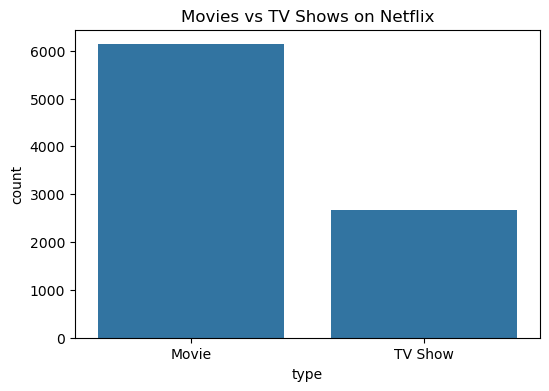

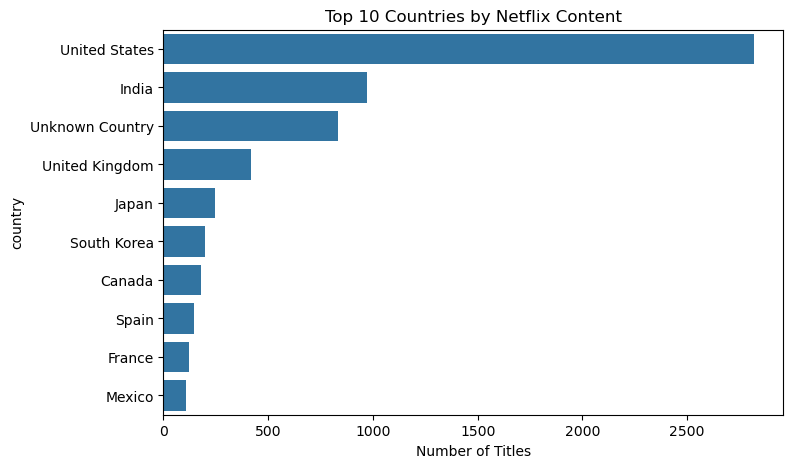

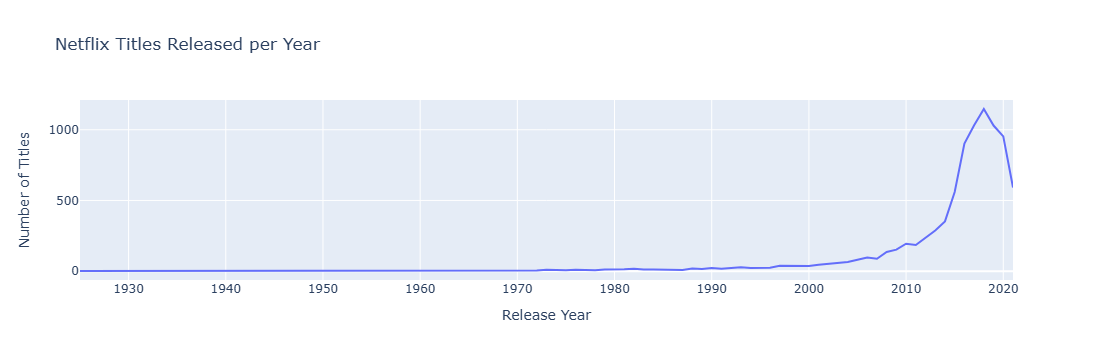

In [14]:
# ---------------------------------------------
# 4️⃣ EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------

# Movies vs TV Shows
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

# Top 10 countries by content
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(y=top_countries.index, x=top_countries.values)
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.show()

# Titles released per year
year_counts = df['release_year'].value_counts().sort_index()
fig = px.line(x=year_counts.index, y=year_counts.values,
              labels={'x':'Release Year', 'y':'Number of Titles'},
              title="Netflix Titles Released per Year")
fig.show()

In [15]:
# ---------------------------------------------
# 5️⃣ TEXT-BASED RECOMMENDATION SYSTEM
# ---------------------------------------------
# Build TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['text_features'])

# Cosine similarity
cos_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Map titles to indices
indices = pd.Series(df.index, index=df['title'])

def recommend(title, n=5):
    if title not in indices:
        print("Title Not Found! Try another.")
        return
    idx = indices[title]
    sim_scores = list(enumerate(cos_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    print(f"Recommendations for '{title}':")
    for i, (idx, score) in enumerate(sim_scores, start=1):
        print(f"{i}. {df.iloc[idx]['title']}")

# Interactive widget
interact(recommend,
         title=widgets.Dropdown(options=df['title'].unique(), description="Select Title:"),
         n=widgets.IntSlider(min=1, max=10, value=5, description="Top N:"))

interactive(children=(Dropdown(description='Select Title:', options=('Dick Johnson Is Dead', 'Blood & Water', …

<function __main__.recommend(title, n=5)>

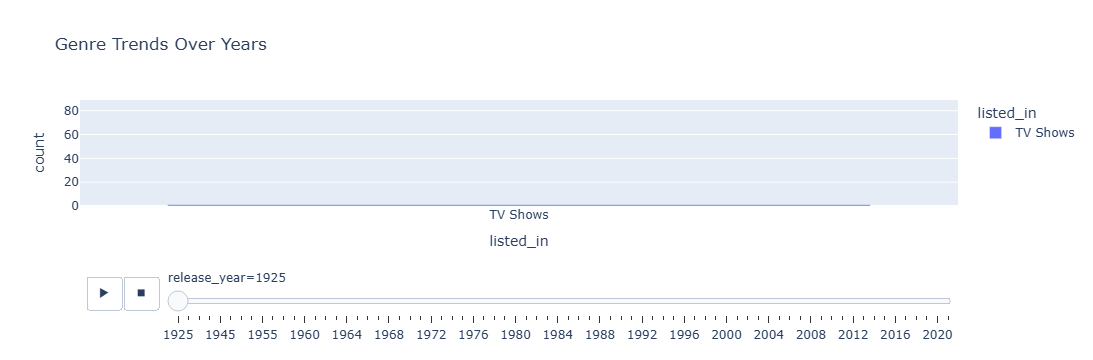

In [16]:
# ---------------------------------------------
# 7️⃣ ANIMATED GENRE TREND OVER YEARS
# ---------------------------------------------
year_genre = df.groupby(['release_year','listed_in']).size().reset_index(name='count')

fig = px.bar(year_genre,
             x='listed_in', y='count', color='listed_in',
             animation_frame='release_year',
             range_y=[0, year_genre['count'].max()],
             title="Genre Trends Over Years")
fig.show()

In [17]:

# ---------------------------------------------
# 8️⃣ ML: PREDICT NEXT YEAR'S MOST POPULAR GENRES
# ---------------------------------------------
genre_year = df.groupby(['release_year','listed_in']).size().unstack(fill_value=0)
next_year = df['release_year'].max() + 1

predictions = {}
for genre in genre_year.columns:
    X = genre_year.index.values.reshape(-1,1)
    y = genre_year[genre].values
    model = LinearRegression()
    model.fit(X, y)
    pred = model.predict([[next_year]])[0]
    predictions[genre] = int(pred)

top5 = sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"Top predicted genres for {next_year}:")
for rank, (genre, count) in enumerate(top5, start=1):
    print(f"{rank}. {genre} ({count} predicted)")

Top predicted genres for 2022:
1. Documentaries (16 predicted)
2. Dramas, International Movies (15 predicted)
3. Stand-Up Comedy (15 predicted)
4. Comedies, Dramas, International Movies (11 predicted)
5. Dramas, Independent Movies, International Movies (11 predicted)


In [18]:
# ---------------------------------------------
# 9️⃣ SAVE CLEANED DATASET
# ---------------------------------------------
df.to_csv("netflix_cleaned.csv", index=False)
print("Cleaned Netflix dataset saved successfully!")

Cleaned Netflix dataset saved successfully!
